In [1]:
import numpy as np
import pandas as pd

# Data repeatable banane ke liye seed value set ki
np.random.seed(42)

# 1,000 employees ka basic data variables generate karna
employee_ids = np.arange(1001, 2001)
daily_hours = np.random.uniform(6, 12, 1000)               # 6 se 12 daily working hours
experience_years = np.random.uniform(1, 10, 1000)          # 1 se 10 saal ka tenure
salary_satisfaction = np.random.randint(1, 6, 1000)        # Scale 1 se 5 (Salary khushi)
promotion_gap_years = np.random.uniform(0, 5, 1000)        # Last promotion se gap (Years)
manager_relation = np.random.randint(1, 6, 1000)           # Scale 1 se 5 (Manager ke sath dosti)

# Normal trend ka base score math formula (Normal noise = Lakshman Rekha ke andar ki chhoti galti)
frustration_score = (
    (daily_hours * 4) + 
    (promotion_gap_years * 5) - 
    (salary_satisfaction * 3) - 
    (manager_relation * 4) + 
    np.random.normal(0, 5, 1000)
)

outlier_condition = (manager_relation <= 2) & (promotion_gap_years >= 3)
frustration_score[outlier_condition] += np.random.uniform(30, 45, size=np.sum(outlier_condition))

# Final output score ko 0 aur 100 percent ke beech lock kiya
frustration_score = np.clip(frustration_score, 0, 100)

# Saare columns ko ek sath Pandas DataFrame me pack kiya
df = pd.DataFrame({
    'Employee_ID': employee_ids,
    'Daily_Hours': daily_hours,
    'Experience_Years': experience_years,
    'Salary_Satisfaction': salary_satisfaction,
    'Promotion_Gap_Years': promotion_gap_years,
    'Manager_Relation': manager_relation,
    'Frustration_Score': frustration_score
})

df.head()


,Employee_ID,Daily_Hours,Experience_Years,Salary_Satisfaction,Promotion_Gap_Years,Manager_Relation,Frustration_Score
0,1001,8.247241,2.666196,4,3.295569,2,70.350190
1,1002,11.704286,5.877109,3,0.544467,5,22.967223
2,1003,10.391964,8.856513,4,3.182693,5,32.427136
3,1004,9.591951,7.590024,2,2.491180,5,28.879145
4,1005,6.936112,8.259050,2,2.033370,3,14.939916


In [2]:
import sqlite3

# Database connection instantiate kiya
conn = sqlite3.connect('lakshmanrekha_metrics.db')

# Pandas ke throw pure dataframe ko database me dump kiya
df.to_sql('employee_metrics', conn, if_exists='replace', index=False)

# Analytics Query: Bad manager with high burnout check karne ke liye
query = """
SELECT Employee_ID, Daily_Hours, Manager_Relation, Frustration_Score 
FROM employee_metrics 
WHERE Manager_Relation <= 2 AND Frustration_Score > 75
ORDER BY Daily_Hours DESC 
LIMIT 5;
"""

# Query run karke metrics fetch kiya
sql_result = pd.read_sql_query(query, conn)

# Resource cleanup
conn.close()

# Preview for verification
sql_result


,Employee_ID,Daily_Hours,Manager_Relation,Frustration_Score
0,1479,11.815815,2,86.578622
1,1314,11.775890,2,81.590472
2,1141,11.774684,2,97.311508
3,1242,11.723571,2,95.734988
4,1790,11.683700,2,83.401449


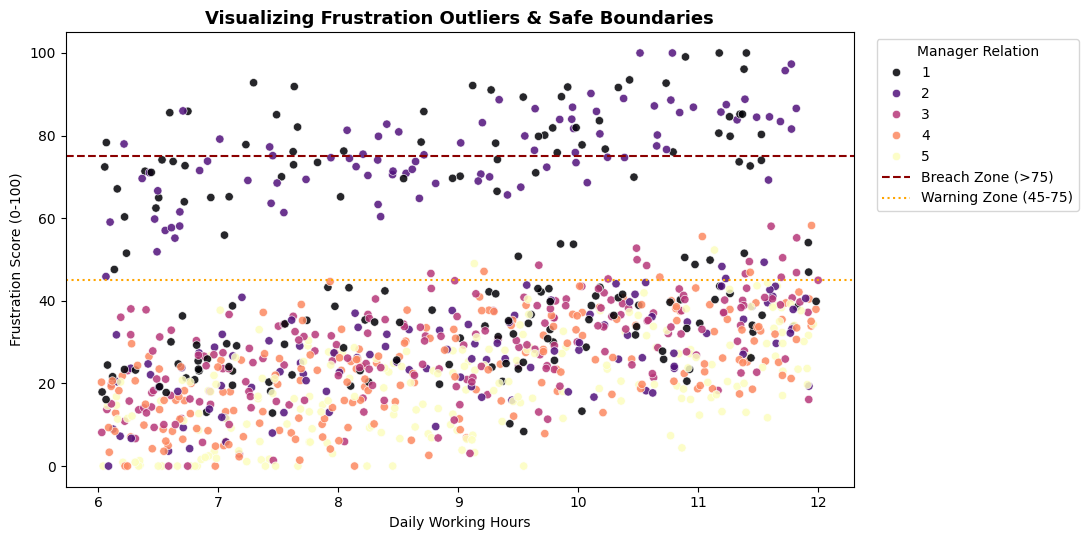

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot canvas layout setup
plt.figure(figsize=(11, 5.5))

# Multi-variable scatter plot generation
sns.scatterplot(
    data=df, 
    x='Daily_Hours', 
    y='Frustration_Score', 
    hue='Manager_Relation', 
    palette='magma', 
    alpha=0.85
)

# Benchmark lines (Lakshman Rekha Thresholds)
plt.axhline(y=75, color='darkred', linestyle='--', label='Breach Zone (>75)')
plt.axhline(y=45, color='orange', linestyle=':', label='Warning Zone (45-75)')

# Formatting plot cosmetics
plt.title("Visualizing Frustration Outliers & Safe Boundaries", fontsize=13, weight='bold')
plt.xlabel("Daily Working Hours")
plt.ylabel("Frustration Score (0-100)")
plt.legend(title='Manager Relation', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [4]:
df.describe

<bound method NDFrame.describe of      Employee_ID  Daily_Hours  Experience_Years  Salary_Satisfaction  \
0           1001     8.247241          2.666196                    4   
1           1002    11.704286          5.877109                    3   
2           1003    10.391964          8.856513                    4   
3           1004     9.591951          7.590024                    2   
4           1005     6.936112          8.259050                    2   
..           ...          ...               ...                  ...   
995         1996     6.549492          6.912596                    3   
996         1997    11.503881          9.609532                    5   
997         1998     6.820912          1.620622                    2   
998         1999    11.701424          1.513492                    3   
999         2000     8.676035          3.539684                    4   

     Promotion_Gap_Years  Manager_Relation  Frustration_Score  
0               3.295569             

In [5]:
df.tail()

,Employee_ID,Daily_Hours,Experience_Years,Salary_Satisfaction,Promotion_Gap_Years,Manager_Relation,Frustration_Score
995,1996,6.549492,6.912596,3,2.802899,4,15.913932
996,1997,11.503881,9.609532,5,4.713296,4,33.717035
997,1998,6.820912,1.620622,2,0.413670,1,29.285354
998,1999,11.701424,1.513492,3,1.269689,5,17.064920
999,2000,8.676035,3.539684,4,3.899942,2,64.806930


In [6]:
df['Salary_Satisfaction'].unique()

array([4, 3, 2, 1, 5], dtype=int32)

In [7]:
df.isnull().sum()

Employee_ID            0
Daily_Hours            0
Experience_Years       0
Salary_Satisfaction    0
Promotion_Gap_Years    0
Manager_Relation       0
Frustration_Score      0
dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Independent features (X) aur target (y) select kiya
X = df[['Daily_Hours', 'Experience_Years', 'Salary_Satisfaction', 'Promotion_Gap_Years', 'Manager_Relation']]
y = df['Frustration_Score']

# Data ko train aur test sets me split kiya (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVR ke liye Scaling mandatory hai, isliye StandardScaler use kiya
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Features ko scale (standardize) kiya
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Target variable ko 2D array me badal kar scale kiya aur wapas 1D kiya
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

# Shape check karne ke liye print
print(f"Training shape: {X_train_scaled.shape}, Testing shape: {X_test_scaled.shape}")


Training shape: (800, 5), Testing shape: (200, 5)


In [9]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score

# SVR initialize kiya with RBF kernel
# C=100 (Outliers handle karne ke liye strict) aur epsilon=0.1 (Lakshman Rekha width)
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train_scaled)

# Predictions calculate kiya test set par
y_pred_scaled = svr_model.predict(X_test_scaled)

# Scaled predictions ko wapas actual format me inverse transform kiya
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Metrics calculate kiya validation ke liye
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R2 Score: {r2:.2f}")


Model Performance Metrics:
Mean Absolute Error (MAE): 6.29
R2 Score: 0.87


In [10]:
import joblib

# Trained model ko production file me dump kiya
joblib.dump(svr_model, 'lakshmanrekha_svr_model.pkl')

# Scalers ko save kiya taaki website par live user inputs scale ho sakein
joblib.dump(scaler_X, 'scaler_x.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print("All artifacts exported successfully. Ready for PyCharm deployment!")


All artifacts exported successfully. Ready for PyCharm deployment!
